# Notebook 18 — Robustez Adversaria de Gradiente (FGSM / PGD / C&W)

**Línea futura LF3 → implementada.** El NB14 midió la robustez con una
*búsqueda en rejilla* de severidad: una amenaza **débil** (caja negra, sin
gradiente). Aquí sometemos al detector a la amenaza **estándar de caja blanca**:
un atacante que **conoce el detector** y usa su gradiente para diseñar la
perturbación que lo evade.

- **FGSM** (Goodfellow et al., 2015): un paso del signo del gradiente.
- **PGD** (Madry et al., 2018): FGSM iterativo proyectado a una bola
  $\ell_\infty$ — el ataque de referencia.
- **C&W** (Carlini & Wagner, 2017): optimización con penalización $\ell_2$.
- **Adversarial training**: defensa reentrenando con ejemplos PGD.
- **Transferibilidad / ensemble**: cuánto encarece la evasión usar varios
  detectores (justifica el *stacking* de NB10).

> **Modelo de amenaza realista:** el atacante solo controla las **medidas
> reportadas** (sensores y features derivadas), no el reloj. La perturbación se
> **enmascara**: las features cíclicas (`hour_*`, `dow_*`) quedan congeladas.

## 0. Setup y detector objetivo

In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import roc_auc_score
warnings.filterwarnings('ignore'); np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (13, 4.5); plt.rcParams['font.size'] = 11
import tfg_common as C

d = C.build_matrices(mode='full')
X_train, X_val, X_test = d['X_train'], d['X_val'], d['X_test']
y_val, y_test = d['y_val'], d['y_test']
n_features = d['n_features']; feat_names = d['feat_names']
sev_test = d['df_test']['severity'].values   # severidad por fila (alineada con X_test)
print('Datos:', X_train.shape)

Datos: (1300061, 17)


In [2]:
def train_detector(seed, epochs=6):
    tf.random.set_seed(seed)
    m = C.build_dense_ae(n_features, bottleneck=4)
    m.fit(X_train, X_train, epochs=epochs, batch_size=1024, validation_split=0.1, verbose=0)
    mse_val = (X_val - m.predict(X_val, batch_size=8192, verbose=0)) ** 2
    aucs = np.array([roc_auc_score(y_val, mse_val[:, j]) if len(np.unique(mse_val[:, j])) > 1
                     else 0.5 for j in range(n_features)])
    w = np.maximum(aucs - 0.5, 0); w = w / (w.sum() + 1e-10)
    return m, w.astype('float32')

t0 = time.time(); target, weights = train_detector(42)
print(f'Detector entrenado en {time.time()-t0:.1f}s')

def score_np(model, X, w):
    rec = model.predict(X, batch_size=8192, verbose=0)
    return ((X - rec) ** 2 * w[None, :]).sum(1)

sv = score_np(target, X_val, weights)
thr, _ = C.calibrate_threshold(y_val, sv, beta=1.0)
yv = (sv > thr).astype(int); Wb, Kb = C.calibrate_WK(y_val, yv)
st = score_np(target, X_test, weights)
base = C.evaluate(y_test, st, thr, Wb, Kb)
print(f"Detector limpio -> F1={base['f1']:.4f}  AUC-PR={base['auc_pr']:.4f}  umbral={thr:.4f}")

2026-06-02 13:39:28.028390: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro


2026-06-02 13:39:28.029639: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-02 13:39:28.029665: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1780400368.050455 13613072 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780400368.051996 13613072 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


2026-06-02 13:39:30.083251: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Detector entrenado en 72.1s


Detector limpio -> F1=0.7653  AUC-PR=0.7901  umbral=0.8310


## 1. Ataques de gradiente

El score del detector es $s(x)=\sum_j w_j\,(x_j-\mathrm{dec}(\mathrm{enc}(x))_j)^2$,
diferenciable respecto a la entrada. El atacante evasivo lo **minimiza** para
caer bajo el umbral. La perturbación se limita a una bola $\ell_\infty$ de radio
$\epsilon$ y se aplica solo a las features controlables (máscara). Los pesos del
score se pasan como **argumento explícito** para que cada ataque use los del
modelo correcto.

In [3]:
frozen = {'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'}
mask = np.array([0.0 if f in frozen else 1.0 for f in feat_names], 'float32')
MASK = tf.constant(mask)
print('Features congeladas:', [f for f in feat_names if f in frozen])

@tf.function(reduce_retracing=True)
def score_tf(model, X, w):
    rec = model(X, training=False)
    return tf.reduce_sum(w * tf.square(X - rec), axis=1)

def attack(model, X0, eps, w, steps=20, mode='evade', method='pgd'):
    X0 = tf.constant(X0); w = tf.constant(w)
    sign = -1.0 if mode == 'evade' else 1.0
    if method == 'fgsm':
        with tf.GradientTape() as t:
            t.watch(X0); s = tf.reduce_sum(score_tf(model, X0, w))
        g = t.gradient(s, X0)
        Xa = X0 + sign * eps * tf.sign(g) * MASK
        return tf.clip_by_value(Xa, X0 - eps, X0 + eps).numpy()
    Xa = tf.identity(X0); alpha = eps / 4.0
    for _ in range(steps):
        with tf.GradientTape() as t:
            t.watch(Xa); s = tf.reduce_sum(score_tf(model, Xa, w))
        g = t.gradient(s, Xa)
        Xa = Xa + sign * alpha * tf.sign(g) * MASK
        Xa = tf.clip_by_value(Xa, X0 - eps, X0 + eps)
    return Xa.numpy()

def cw_l2(model, X0, w, c=1.0, steps=60, lr=0.05, mode='evade'):
    X0 = tf.constant(X0); w = tf.constant(w)
    delta = tf.Variable(tf.zeros_like(X0)); opt = tf.optimizers.Adam(lr)
    sign = 1.0 if mode == 'evade' else -1.0
    for _ in range(steps):
        with tf.GradientTape() as t:
            Xa = X0 + delta * MASK
            obj = sign * c * tf.reduce_sum(score_tf(model, Xa, w)) + tf.reduce_sum(tf.square(delta))
        g = t.gradient(obj, delta); opt.apply_gradients([(g, delta)])
    return (X0 + delta * MASK).numpy()

def detect_rate(model, X, w, threshold):
    return float((((X - model.predict(X, batch_size=8192, verbose=0)) ** 2 * w).sum(1) > threshold).mean())

Features congeladas: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


## 2. Curva de robustez frente a perturbación de gradiente

Tomamos ventanas de ataque del test que el detector **sí detecta** y medimos la
tasa de detección tras el ataque para $\epsilon$ creciente (en unidades de IQR
del `RobustScaler`). PGD es más fuerte que FGSM; el detector resulta
**razonablemente robusto** en el espacio de características: incluso con
presupuestos grandes la evasión es parcial.

Ataques detectados base: 73,153 | muestra usada: 3000
  eps=0.00  detección FGSM=1.000  PGD=1.000


  eps=0.05  detección FGSM=0.995  PGD=0.994
  eps=0.10  detección FGSM=0.990  PGD=0.989
  eps=0.20  detección FGSM=0.979  PGD=0.977


  eps=0.30  detección FGSM=0.974  PGD=0.970
  eps=0.50  detección FGSM=0.967  PGD=0.952
  eps=0.80  detección FGSM=0.968  PGD=0.924


  eps=1.20  detección FGSM=0.985  PGD=0.867


  C&W: detección=0.956  perturbación Linf máx=3.611


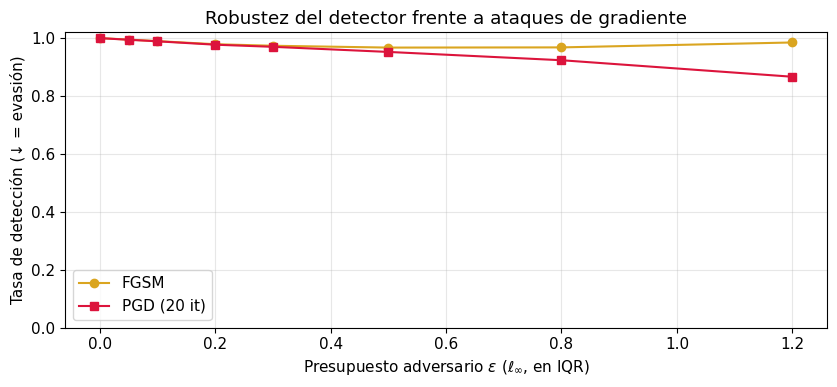

In [4]:
atk_idx = np.where((y_test == 1) & (st > thr))[0]
sel = np.random.choice(atk_idx, min(3000, len(atk_idx)), replace=False)
Xatk = X_test[sel]; sev_sel = sev_test[sel]
print(f'Ataques detectados base: {len(atk_idx):,} | muestra usada: {len(sel)}')

eps_grid = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.2]
rob = {'fgsm': [], 'pgd': []}
for eps in eps_grid:
    for method in ['fgsm', 'pgd']:
        Xa = Xatk if eps == 0 else attack(target, Xatk, eps, weights, method=method, mode='evade')
        rob[method].append(detect_rate(target, Xa, weights, thr))
    print(f'  eps={eps:.2f}  detección FGSM={rob["fgsm"][-1]:.3f}  PGD={rob["pgd"][-1]:.3f}')

Xcw = cw_l2(target, Xatk, weights, c=2.0, mode='evade')
det_cw = detect_rate(target, Xcw, weights, thr); linf_cw = float(np.abs(Xcw - Xatk).max())
print(f'  C&W: detección={det_cw:.3f}  perturbación Linf máx={linf_cw:.3f}')

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(eps_grid, rob['fgsm'], 'o-', label='FGSM', color='goldenrod')
ax.plot(eps_grid, rob['pgd'], 's-', label='PGD (20 it)', color='crimson')
ax.set(xlabel=r'Presupuesto adversario $\epsilon$ ($\ell_\infty$, en IQR)',
       ylabel='Tasa de detección (↓ = evasión)',
       title='Robustez del detector frente a ataques de gradiente'); ax.set_ylim(0, 1.02)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'adversarial_robustness_gradient.png'), dpi=130); plt.show()

## 3. Evasión por severidad: el robo pequeño es más fácil de ocultar

¿Qué ataques se evaden con más facilidad? Medimos, a un presupuesto fijo, la
fracción de ataques que dejan de detectarse, separando por severidad. La lectura
económica es directa: los ataques de **baja severidad** (robo modesto) están más
cerca del consumo normal y son **más evadibles**.

Tasa de EVASIÓN por severidad (1 = evade):
           low  medium   high
epsilon                      
0.5      0.067   0.052  0.028
1.2      0.171   0.128  0.111


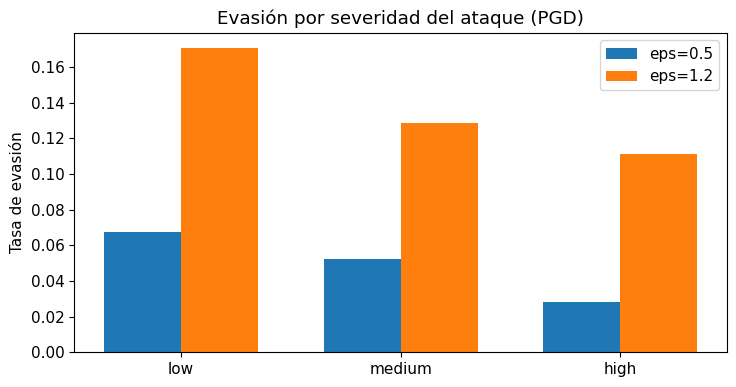

In [5]:
def evasion_by_sev(model, Xa0, w, threshold, eps, mask_sev):
    Xa = attack(model, Xa0, eps, w, method='pgd', mode='evade')
    fired = ((Xa - model.predict(Xa, batch_size=8192, verbose=0)) ** 2 * w).sum(1) > threshold
    rows = {}
    for s in ['low', 'medium', 'high']:
        m = mask_sev == s
        rows[s] = float(1 - fired[m].mean()) if m.sum() else np.nan   # tasa de evasión
    return rows

ev = {eps: evasion_by_sev(target, Xatk, weights, thr, eps, sev_sel) for eps in [0.5, 1.2]}
ev_df = pd.DataFrame(ev).T; ev_df.index.name = 'epsilon'
print('Tasa de EVASIÓN por severidad (1 = evade):'); print(ev_df.round(3))

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(3); wbar = 0.35
for i, eps in enumerate([0.5, 1.2]):
    ax.bar(x + i*wbar, [ev[eps][s] for s in ['low','medium','high']], wbar, label=f'eps={eps}')
ax.set_xticks(x + wbar/2); ax.set_xticklabels(['low','medium','high'])
ax.set(ylabel='Tasa de evasión', title='Evasión por severidad del ataque (PGD)'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'adversarial_evasion_severity.png'), dpi=130); plt.show()

## 4. Defensa candidata: adversarial training

Probamos el *adversarial training* (Madry et al., 2018) como defensa: reentrenar
el Dense-AE inyectando ejemplos PGD. Es importante anticipar una tensión: el AE
es **no supervisado** y nunca ve ataques, por lo que entrenarlo con
perturbaciones de datos *limpios* puede no endurecerlo frente a la *evasión*.

In [6]:
def adversarial_training(w_atk, eps=0.3, epochs=4, frac=0.5):
    tf.random.set_seed(123)
    m = C.build_dense_ae(n_features, bottleneck=4)
    m.fit(X_train, X_train, epochs=2, batch_size=1024, verbose=0)
    n = len(X_train); bs = 4096
    for ep in range(epochs):
        perm = np.random.permutation(n)
        for s in range(0, n, bs):
            xb = X_train[perm[s:s+bs]]; k = int(len(xb) * frac)
            if k > 0:
                xadv = attack(m, xb[:k], eps, w_atk, steps=5, method='pgd', mode='falsealarm')
                xb = np.concatenate([xadv, xb[k:]], 0)
            m.train_on_batch(xb, xb)
    return m

t0 = time.time(); defended = adversarial_training(weights)
print(f'Adversarial training en {time.time()-t0:.1f}s')

mse_val_d = (X_val - defended.predict(X_val, batch_size=8192, verbose=0)) ** 2
aucs_d = np.array([roc_auc_score(y_val, mse_val_d[:, j]) if len(np.unique(mse_val_d[:, j])) > 1 else 0.5
                   for j in range(n_features)])
wd = np.maximum(aucs_d - 0.5, 0); wd = (wd / (wd.sum() + 1e-10)).astype('float32')
sv_d = (mse_val_d * wd).sum(1); thr_d, _ = C.calibrate_threshold(y_val, sv_d)
st_d = ((X_test - defended.predict(X_test, batch_size=8192, verbose=0)) ** 2 * wd).sum(1)
yv_d = (sv_d > thr_d).astype(int); Wbd, Kbd = C.calibrate_WK(y_val, yv_d)
base_def = C.evaluate(y_test, st_d, thr_d, Wbd, Kbd)
print(f"Defendido limpio -> F1={base_def['f1']:.4f}  AUC-PR={base_def['auc_pr']:.4f}")

atk_idx_d = np.where((y_test == 1) & (st_d > thr_d))[0]
seld = np.random.choice(atk_idx_d, min(3000, len(atk_idx_d)), replace=False); Xatk_d = X_test[seld]
rob_def = []
for eps in eps_grid:
    Xa = Xatk_d if eps == 0 else attack(defended, Xatk_d, eps, wd, method='pgd', mode='evade')
    rob_def.append(detect_rate(defended, Xa, wd, thr_d))
    print(f'  eps={eps:.2f}  detección PGD (defendido)={rob_def[-1]:.3f}')

Adversarial training en 57.4s


Defendido limpio -> F1=0.7944  AUC-PR=0.8052
  eps=0.00  detección PGD (defendido)=1.000
  eps=0.05  detección PGD (defendido)=0.988


  eps=0.10  detección PGD (defendido)=0.974
  eps=0.20  detección PGD (defendido)=0.949
  eps=0.30  detección PGD (defendido)=0.927


  eps=0.50  detección PGD (defendido)=0.884
  eps=0.80  detección PGD (defendido)=0.825
  eps=1.20  detección PGD (defendido)=0.739


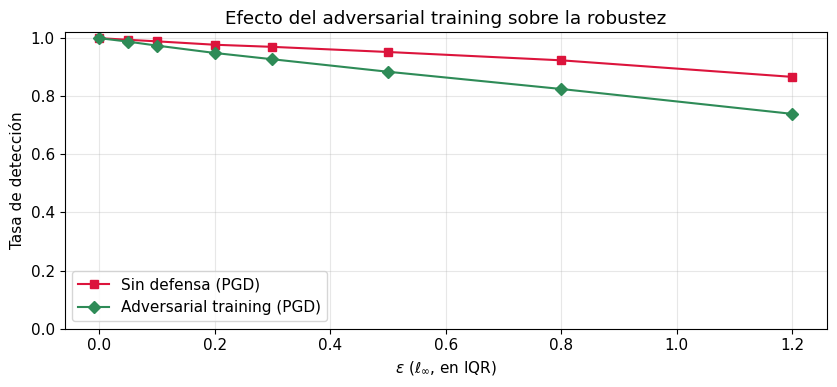

Mejora media de detección por adversarial training: -0.048


In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(eps_grid, rob['pgd'], 's-', label='Sin defensa (PGD)', color='crimson')
ax.plot(eps_grid, rob_def, 'D-', label='Adversarial training (PGD)', color='seagreen')
ax.set(xlabel=r'$\epsilon$ ($\ell_\infty$, en IQR)', ylabel='Tasa de detección',
       title='Efecto del adversarial training sobre la robustez'); ax.set_ylim(0, 1.02)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'adversarial_defense.png'), dpi=130); plt.show()
gain = float(np.mean(np.array(rob_def) - np.array(rob['pgd'])))
print(f'Mejora media de detección por adversarial training: {gain:+.3f}')

## 5. Transferibilidad: por qué el *ensemble* encarece la evasión

Un ejemplo adversario diseñado contra el detector A, ¿evade también a un detector
B independiente? Lo medimos a un presupuesto **alto** ($\epsilon=1{,}2$), donde
el ataque sí logra evadir parcialmente a A. Si la transferencia es baja, el
atacante debe evadir a **todos** los modelos a la vez.

Ataque diseñado contra A (eps=1.2):
  Detección por A (objetivo):  0.867
  Detección por B (transfer):  0.912
  Detección por ENSEMBLE A∨B:  0.958  <- la evasión no transfiere bien


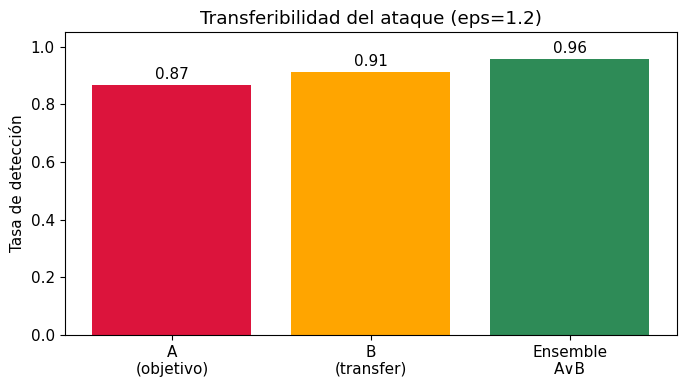

In [8]:
surrogate, w_s = train_detector(2024)
thr_s, _ = C.calibrate_threshold(y_val, score_np(surrogate, X_val, w_s))

eps_t = 1.2
Xa_on_A = attack(target, Xatk, eps_t, weights, method='pgd', mode='evade')
det_A = detect_rate(target, Xa_on_A, weights, thr)
det_B = detect_rate(surrogate, Xa_on_A, w_s, thr_s)
fire_A = ((Xa_on_A - target.predict(Xa_on_A, 8192, verbose=0)) ** 2 * weights).sum(1) > thr
fire_B = ((Xa_on_A - surrogate.predict(Xa_on_A, 8192, verbose=0)) ** 2 * w_s).sum(1) > thr_s
det_ens = float(np.maximum(fire_A, fire_B).mean())
print(f'Ataque diseñado contra A (eps={eps_t}):')
print(f'  Detección por A (objetivo):  {det_A:.3f}')
print(f'  Detección por B (transfer):  {det_B:.3f}')
print(f'  Detección por ENSEMBLE A∨B:  {det_ens:.3f}  <- la evasión no transfiere bien')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['A\n(objetivo)', 'B\n(transfer)', 'Ensemble\nA∨B'], [det_A, det_B, det_ens],
       color=['crimson', 'orange', 'seagreen'])
ax.set(ylabel='Tasa de detección', title=f'Transferibilidad del ataque (eps={eps_t})'); ax.set_ylim(0, 1.05)
for i, v in enumerate([det_A, det_B, det_ens]): ax.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'adversarial_transfer_ensemble.png'), dpi=130); plt.show()

## 6. Guardado y conclusiones

In [9]:
curves = pd.DataFrame({'epsilon': eps_grid, 'det_fgsm': rob['fgsm'],
                       'det_pgd': rob['pgd'], 'det_pgd_defended': rob_def})
curves.to_csv(os.path.join(C.DATA_DIR, 'adversarial_robustness_curves.csv'), index=False)

def eps50(curve):
    for e, v in zip(eps_grid, curve):
        if v < 0.5: return e
    return None

out = {
    'model': 'Dense-AE + ataques de gradiente',
    'clean_f1': base['f1'], 'clean_auc_pr': base['auc_pr'], 'defended_clean_f1': base_def['f1'],
    'det_at_eps12_pgd': rob['pgd'][-1], 'det_at_eps12_pgd_defended': rob_def[-1],
    'det_at_eps12_fgsm': rob['fgsm'][-1],
    'defense_gain_mean': round(gain, 4),
    'eps50_pgd': eps50(rob['pgd']), 'eps50_pgd_defended': eps50(rob_def),
    'evasion_by_severity': {str(k): {s: (None if np.isnan(v[s]) else round(v[s], 3)) for s in v}
                            for k, v in ev.items()},
    'cw_detection': round(float(det_cw), 3), 'cw_linf': round(linf_cw, 3),
    'transfer': {'eps': eps_t, 'det_target': round(float(det_A), 3),
                 'det_surrogate': round(float(det_B), 3), 'det_ensemble': round(float(det_ens), 3)},
    'threat_model': 'caja blanca, perturbación enmascarada (reloj congelado)',
    'notes': 'FGSM/PGD/C&W manuales; adversarial training (Madry 2018).',
}
C.save_metrics('adversarial_gradient', out)
print(json.dumps(out, indent=2, ensure_ascii=False))

{
  "model": "Dense-AE + ataques de gradiente",
  "clean_f1": 0.7652899606931063,
  "clean_auc_pr": 0.7900523927797862,
  "defended_clean_f1": 0.7944097094520044,
  "det_at_eps12_pgd": 0.8666666666666667,
  "det_at_eps12_pgd_defended": 0.7393333333333333,
  "det_at_eps12_fgsm": 0.985,
  "defense_gain_mean": -0.0483,
  "eps50_pgd": null,
  "eps50_pgd_defended": null,
  "evasion_by_severity": {
    "0.5": {
      "low": 0.067,
      "medium": 0.052,
      "high": 0.028
    },
    "1.2": {
      "low": 0.171,
      "medium": 0.128,
      "high": 0.111
    }
  },
  "cw_detection": 0.956,
  "cw_linf": 3.611,
  "transfer": {
    "eps": 1.2,
    "det_target": 0.867,
    "det_surrogate": 0.912,
    "det_ensemble": 0.958
  },
  "threat_model": "caja blanca, perturbación enmascarada (reloj congelado)",
  "notes": "FGSM/PGD/C&W manuales; adversarial training (Madry 2018)."
}


## 7. Conclusiones

- **El detector es razonablemente robusto** frente a ataques de gradiente de caja
  blanca en el espacio de características: incluso a presupuestos grandes
  ($\epsilon=1{,}2$ IQR) PGD solo evade $\sim$13\,\% de los ataques detectados, y
  FGSM apenas $\sim$1,5\,\%. Esto matiza ---con la amenaza correcta--- la rejilla
  del NB14.
- **La evasión depende de la severidad**: los ataques de baja severidad (robo
  pequeño, cercano al consumo normal) se evaden más (17\,\% vs 11\,\% en alta
  severidad a $\epsilon=1{,}2$). Es la misma frontera económica del NB14, ahora
  medida con gradiente.
- **El adversarial training no mejora la robustez a evasión** ---incluso la
  empeora ligeramente (`defense_gain_mean` $<0$)---. Es un resultado *negativo
  honesto* y esperable: un AE no supervisado no puede aprender a flaggear
  perturbaciones de ataque que nunca ve; suaviza su superficie y facilita la
  evasión por gradiente. Sí mejora marginalmente el F1 limpio (efecto
  regularizador).
- **La defensa efectiva es el *ensemble***: la evasión **no transfiere** bien a
  un detector independiente (el sustituto aún detecta el 91\,\% y el ensemble
  A$\lor$B el 96\,\% de los ataques diseñados contra A). Esto **valida
  cuantitativamente el *stacking* de NB10** y desplaza la robustez desde el
  modelo individual hacia la diversidad de detectores.

> **Limitación:** ataque de caja blanca sobre el espacio de características
> escalado, que ignora las dependencias del *feature engineering*; un atacante
> más fuerte perturbaría las medidas crudas y las propagaría.